# K-Mean Clustering Algorithm with Scikit-Learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

## Gernerate some random datapoints

In [2]:
x, y= make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

## Scale the features so distance calculation are accurate 

In [3]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(x)

Visualising the dataset before creating cluster

In [4]:
plt.scatter(X[:,0], X[:,1], s=50);

NameError: name 'X' is not defined

# First Method to find the optimum cluster in K-means

### WCSS Method and Elbow Method can be used to find no. of optimum clusters
 

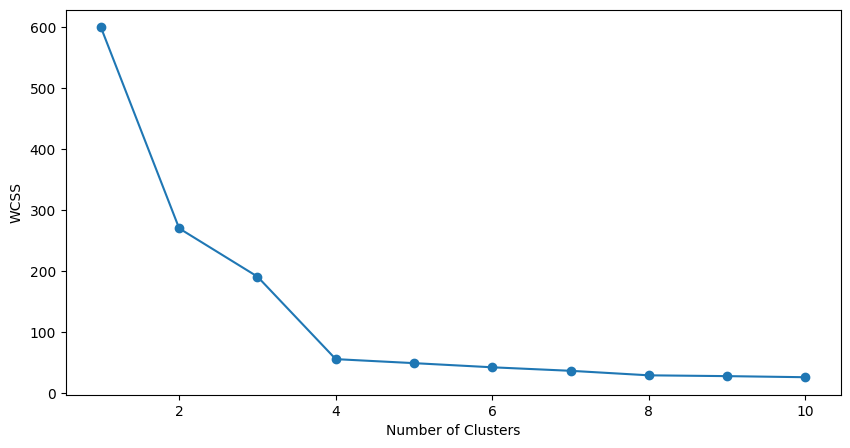

In [6]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Second method to check the optimum no. of cluster in Silhouette Score

### Maximum value of silhoutte score gives the optimum no. of clusters

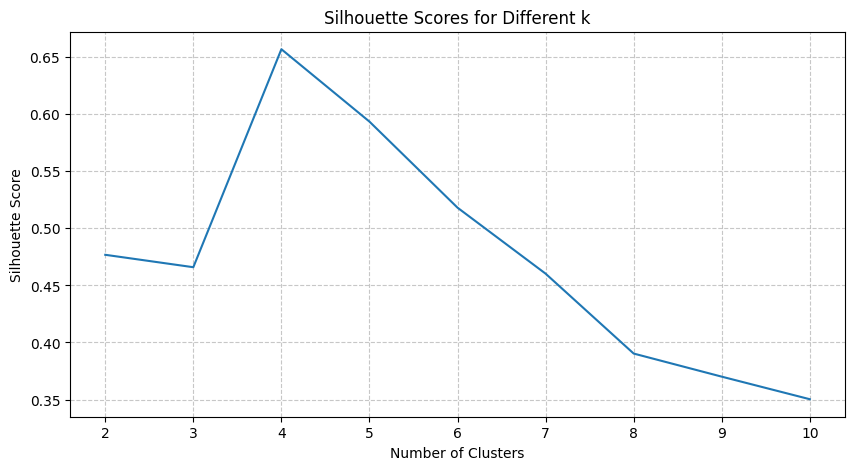

In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores)
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
optimum_k =4
kmeans = KMeans(n_clusters=optimum_k, init='k-means++', random_state=42)

In [9]:
cluster_labels =kmeans.fit_predict(X_scaled)
centroids =kmeans.cluster_centers_

print("Cluster labels:", cluster_labels)
print("Centroids:",centroids)

Cluster labels: [0 1 2 1 0 0 3 2 1 1 3 1 2 1 0 2 2 0 3 3 0 0 2 3 3 2 0 2 3 2 1 1 2 1 1 1 1
 1 3 0 2 3 2 2 3 3 1 3 1 0 3 0 1 0 0 3 1 3 1 0 1 2 1 3 3 3 1 0 1 3 2 3 1 3
 3 1 3 2 0 1 0 2 0 0 1 2 0 2 1 1 2 0 1 3 3 2 0 0 2 3 1 0 1 0 2 0 0 2 1 2 3
 3 0 1 0 2 1 0 0 2 3 0 3 0 0 0 0 3 0 3 1 3 3 0 1 3 3 1 2 1 1 3 2 3 2 3 1 2
 1 1 1 2 1 2 0 3 1 3 0 2 1 2 2 0 2 3 3 2 0 2 2 1 0 2 3 1 0 0 2 3 0 2 3 3 2
 2 2 2 0 1 2 3 2 2 3 3 3 2 3 1 2 3 0 3 2 1 3 1 2 1 2 3 2 2 1 3 3 0 0 2 1 0
 0 3 0 3 2 1 1 2 2 1 2 0 3 2 0 3 1 3 0 2 0 1 1 1 1 3 3 1 2 3 0 2 3 3 3 0 0
 1 2 2 3 0 1 3 2 1 2 0 0 3 3 2 0 0 0 2 1 1 0 0 2 0 0 0 1 3 1 2 0 0 1 1 1 0
 0 2 1 3]
Centroids: [[ 1.21774671 -1.19712077]
 [-0.83691948  1.46193015]
 [ 0.58536699  0.17425154]
 [-0.96619422 -0.43906093]]


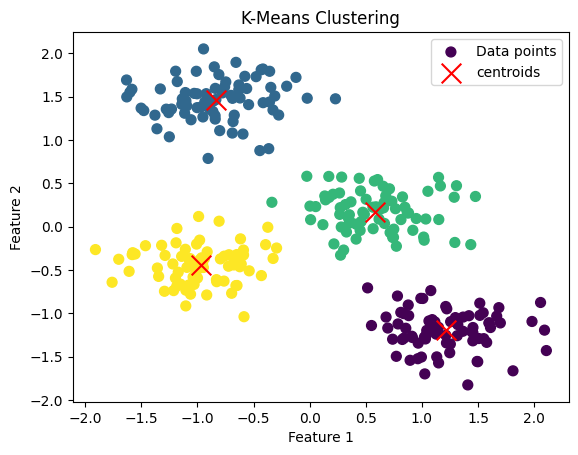

In [11]:
plt.scatter( X_scaled[:,0], X_scaled[:,1] , s=50 , c=cluster_labels,cmap='viridis');
plt.scatter(centroids[:,0], centroids[:, 1], s=200, c='red', marker='x');
plt.title('K-Means Clustering');
plt.xlabel('Feature 1');
plt.ylabel('Feature 2');
plt.legend(['Data points', 'centroids'])
plt.show()